In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [44]:
energy_df = pd.read_csv(r'C:\Users\firea\Desktop\uwu\Intelligent_abnormal_electricity_usage_dataset_REALWORLD.csv')

In [45]:
energy_df.shape

(10800, 15)

In [46]:
energy_df.dtypes

Meter_Id                    object
Date                        object
Region_Code                 object
Dwelling_Type               object
Num_Occupants                int64
House_Area (sqft)            int64
Appliance_Score              int64
Connected_Load(kw)         float64
Temperature_C              float64
Humidity (%)               float64
Expected_Energy(kwh)        object
Actual_Energy(kwh)          object
Usage_Deviation(%)         float64
Cluster_Avg_Energy(kwh)    float64
Abnormal_Usage               int64
dtype: object

In [47]:
energy_df.isnull().sum()

Meter_Id                     0
Date                         0
Region_Code                  0
Dwelling_Type                0
Num_Occupants                0
House_Area (sqft)            0
Appliance_Score              0
Connected_Load(kw)           0
Temperature_C                0
Humidity (%)                 0
Expected_Energy(kwh)       667
Actual_Energy(kwh)         900
Usage_Deviation(%)           0
Cluster_Avg_Energy(kwh)      0
Abnormal_Usage               0
dtype: int64

In [48]:
energy_df = energy_df.dropna()

In [49]:
energy_df = energy_df.drop(columns=['Meter_Id'], errors='ignore')

In [50]:
energy_df.dtypes

Date                        object
Region_Code                 object
Dwelling_Type               object
Num_Occupants                int64
House_Area (sqft)            int64
Appliance_Score              int64
Connected_Load(kw)         float64
Temperature_C              float64
Humidity (%)               float64
Expected_Energy(kwh)        object
Actual_Energy(kwh)          object
Usage_Deviation(%)         float64
Cluster_Avg_Energy(kwh)    float64
Abnormal_Usage               int64
dtype: object

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
numeric_cols_with_units = ["Expected_Energy(kwh)", "Actual_Energy(kwh)", "Cluster_Avg_Energy(kwh)"]
for col in numeric_cols_with_units:
    energy_df[col] =energy_df[col].replace('[^\d\.]', '', regex=True).astype(float)

energy_df["Connected_Load(kw)"] = energy_df["Connected_Load(kw)"].replace('[^\d\.]', '', regex=True).astype(float)
X = energy_df.drop(columns=["Date", "Region_Code", "Dwelling_Type", "Abnormal_Usage"])
y = energy_df["Abnormal_Usage"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.993006993006993

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1140
           1       0.99      0.99      0.99       719

    accuracy                           0.99      1859
   macro avg       0.99      0.99      0.99      1859
weighted avg       0.99      0.99      0.99      1859



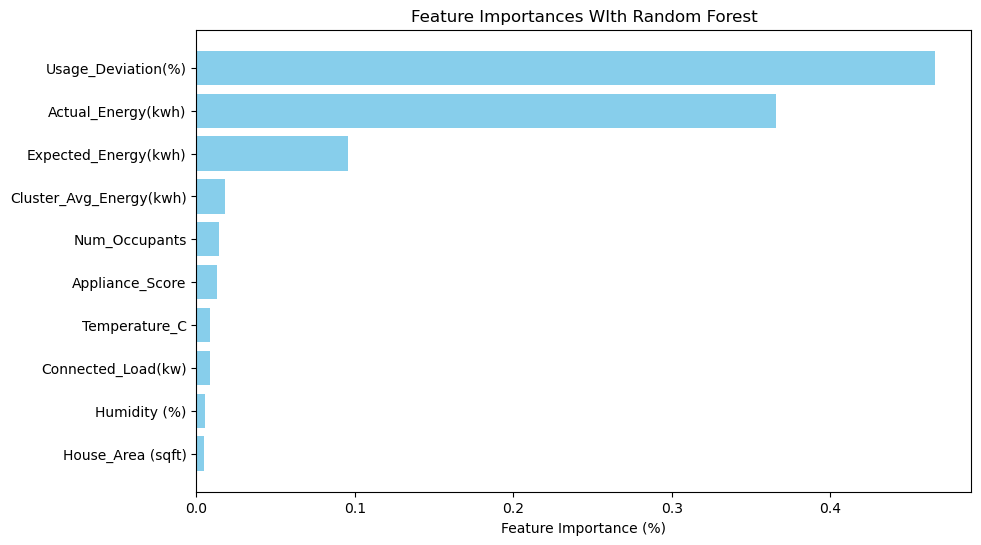

In [65]:
feature_importances = clf.feature_importances_
feature_names = X.columns  
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance (%)')
plt.title('Feature Importances WIth Random Forest')
plt.show()

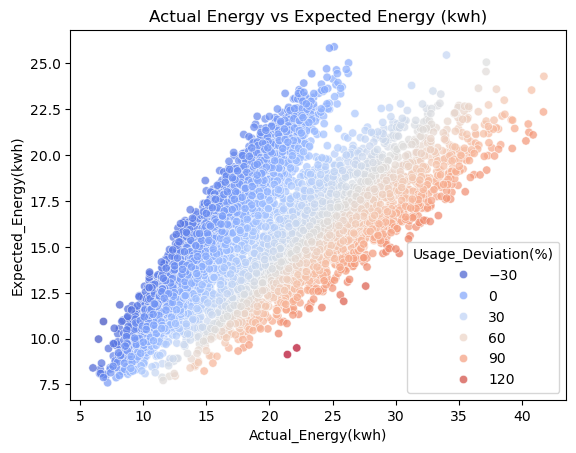

In [62]:
sns.scatterplot(
    data=energy_df,
    x='Actual_Energy(kwh)',
    y='Expected_Energy(kwh)',
    hue= 'Usage_Deviation(%)',
    palette = 'coolwarm',
    alpha=0.7
)

plt.title('Actual Energy vs Expected Energy (kwh)')
plt.show()

In [79]:
energy_df = energy_df.dropna(subset=['Num_Occupants', 'Appliance_Score'])

In [82]:
energy_df.dtypes

Date                         object
Region_Code                  object
Dwelling_Type                object
Num_Occupants              category
House_Area (sqft)             int64
Appliance_Score               int64
Connected_Load(kw)          float64
Temperature_C               float64
Humidity (%)                float64
Expected_Energy(kwh)        float64
Actual_Energy(kwh)          float64
Usage_Deviation(%)          float64
Cluster_Avg_Energy(kwh)     float64
Abnormal_Usage                int64
dtype: object

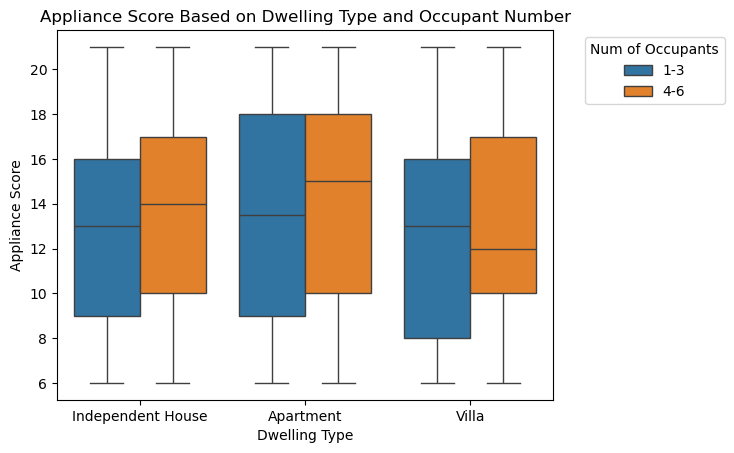

In [85]:
sns.boxplot(
    data=energy_df,
    x='Dwelling_Type',
    y='Appliance_Score',
    hue='Num_Occupants'
)

plt.title('Appliance Score Based on Dwelling Type and Occupant Number')
plt.xlabel('Dwelling Type')
plt.ylabel('Appliance Score')
plt.legend(title='Num of Occupants')
plt.legend(title='Num of Occupants', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
